# PyTorch 회귀분석 재개선 실험: 과소적합 진단 및 교정 (ver.2)


---
## 실패 분석 (1차 개선 시도 결과)

| 모델 | RMSE | Δ RMSE | 해석 |
|------|------|--------|------|
| Baseline | 53.98 | 기준 | — |
| Dropout + WD | 54.24 | **+0.26** | 정규화가 오히려 악화 |
| BN + Scheduler | 65.94 | **+11.96** | LR 과도 억제 |
| Early Stopping | 53.98 | **0** | epoch 500 미발동 |

<br>

---
## 진단: 과소적합 (Underfitting)

**논리적 추론:**

```
전제 1: 정규화(Dropout, WD)는 모델의 학습 용량을 제한한다.
전제 2: 과적합 모델에 정규화를 적용하면 성능이 향상된다.
전제 3: 과소적합 모델에 정규화를 적용하면 성능이 악화된다.
관측:   정규화 적용 후 성능이 악화되었다.
결론:   현재 모델은 과소적합 상태이다.
```

**Early Stopping 미발동의 의미:**
- patience=50 에포크 동안 Val Loss가 지속적으로 개선되었다는 뜻
- 즉, epoch 500에서도 모델은 아직 수렴 중이었을 가능성이 있다

<br>

---
## 올바른 개선 전략

```
과소적합 → 해야 할 것                  → 하지 말아야 할 것
──────────────────────────────────────────────────────────
모델 용량 확장 (더 넓은/깊은 네트워크)    정규화 추가 (Dropout, WD)
학습 에포크 증가 (500 → 1000+)          LR 과도 감소
선형 모델 비교 기준 설정                 BatchNorm 단독 추가
K-Fold CV로 분할 편향 제거
```

**추가 주의 사항 — BN+Scheduler 대폭 악화 원인:**
- `ReduceLROnPlateau(patience=20)`는 에포크당 약 5 배치밖에 없는 이 데이터에서
  20 에포크마다 lr을 0.5배 감소시켜 사실상 학습을 조기에 정지시켰다.
- Scheduler를 사용하려면 `patience`를 데이터 크기에 맞게 충분히 크게 설정해보자,

---
## 0. 공통 설정

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] {device}")

[Device] cuda


In [ ]:
# ── 데이터 로드 (기존과 동일 분할: 재현성 보장) ──────────────────────────────
dataset = load_diabetes()
x, y = dataset.data, dataset.target

x_tv, x_test, y_tv, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED)
x_train, x_val, y_train, y_val = train_test_split(x_tv, y_tv, test_size=0.2, random_state=SEED)

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")


def to_tensor(x_arr, y_arr):
    return (torch.tensor(x_arr, dtype=torch.float32),
            torch.tensor(y_arr, dtype=torch.float32).reshape(-1, 1))

x_train_t, y_train_t = to_tensor(x_train, y_train)
x_val_t,   y_val_t   = to_tensor(x_val,   y_val)
x_test_t,  y_test_t  = to_tensor(x_test,  y_test)

BATCH_SIZE = 64

def make_loader(xt, yt, shuffle):
    return DataLoader(TensorDataset(xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(x_train_t, y_train_t, shuffle=True)
val_loader   = make_loader(x_val_t,   y_val_t,   shuffle=False)

Train: 282 | Val: 71 | Test: 89


In [ ]:
# ── 공통 학습/평가 유틸리티 ──────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            total += criterion(model(xb), yb).item()
    return total / len(loader)


def run_training(model, train_loader, val_loader, criterion, optimizer,
                 num_epochs=1000, patience=100, print_every=200, verbose=True):
    """
    학습 루프. Early Stopping 포함.

    patience 기본값을 100으로 설정:
    - 에포크당 배치 수가 적으므로(~5개) 50 에포크는 너무 짧다.
    - 국소 변동을 허용하면서도 실질적 정체를 탐지하려면 100이 적절하다.
    """
    train_losses, val_losses = [], []
    best_val, best_epoch, no_improve = float("inf"), 0, 0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        t = train_one_epoch(model, train_loader, criterion, optimizer)
        v = evaluate(model, val_loader, criterion)
        train_losses.append(t)
        val_losses.append(v)

        if v < best_val:
            best_val, best_epoch, no_improve = v, epoch, 0
            best_state = {k: w.cpu().clone() for k, w in model.state_dict().items()}
        else:
            no_improve += 1

        if no_improve >= patience:
            if verbose:
                print(f"  [Early Stop] Epoch {epoch} — Best: {best_epoch}")
            break

        if verbose and epoch % print_every == 0:
            print(f"  Epoch {epoch:5d} | Train: {t:7.2f} | Val: {v:7.2f}")

    if best_state:
        model.load_state_dict({k: w.to(device) for k, w in best_state.items()})

    return train_losses, val_losses, best_epoch


def get_metrics(model, label=""):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test_t.to(device)).cpu().numpy().flatten()
    mse  = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_test, y_pred)
    print(f"  [{label:<35}]  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {"label": label, "rmse": rmse, "r2": r2, "y_pred": y_pred}


print("[유틸리티 로드 완료]")

[유틸리티 로드 완료]


---
## 실험 A. 선형 모델 기준점 설정 (Ridge / Lasso)



---


### 왜 선형 모델부터인가?


**원칙:** 딥러닝의 우위는 선형 기저 모델(baseline) 대비 측정해야 한다.

n=442의 소규모, 전처리 완료 데이터에서는 선형 회귀 계열이 MLP보다 강한 경우가 많다.
- 파라미터 수: Ridge(10개) << MLP(2,561개)
- 과적합 위험: Ridge << MLP
- 학습 데이터 의존도: 낮음 << 높음


**가정:** 선형 모델이 MLP와 유사하거나 높은 성능을 보인다면,
이 문제는 비선형 패턴이 적거나 데이터가 부족한 것으로 진단할 수 있다.



---
**Ridge vs Lasso:**
- Ridge(L2): 모든 피처를 사용하되 가중치를 작게 만든다.
- Lasso(L1): 일부 피처 가중치를 0으로 만들어 자동 피처 선택 효과.
- `alpha`는 교차검증(`RidgeCV`)으로 최적화하는 것이 원칙이나, 여기서는 탐색 범위로 비교한다.

In [ ]:
print("[실험 A] 선형 모델 기준점")
print("-" * 60)

linear_results = []

for name, model_sk in [
    ("Ridge(alpha=0.1)",  Ridge(alpha=0.1)),
    ("Ridge(alpha=1.0)",  Ridge(alpha=1.0)),
    ("Ridge(alpha=10.0)", Ridge(alpha=10.0)),
    ("Lasso(alpha=0.1)",  Lasso(alpha=0.1, max_iter=10000)),
    ("Lasso(alpha=1.0)",  Lasso(alpha=1.0, max_iter=10000)),
]:
    model_sk.fit(x_train, y_train)          # 학습 (Train 세트만 사용)
    y_pred = model_sk.predict(x_test)       # 예측 (Test 세트)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    print(f"  [{name:<22}]  RMSE={rmse:.4f}  R²={r2:.4f}")
    linear_results.append({"label": name, "rmse": rmse, "r2": r2})

print()
print("  ★ 참고 기준:  Baseline MLP  RMSE=53.9787  R²=0.4501")

[실험 A] 선형 모델 기준점
------------------------------------------------------------
  [Ridge(alpha=0.1)      ]  RMSE=53.5212  R²=0.4593
  [Ridge(alpha=1.0)      ]  RMSE=56.1514  R²=0.4049
  [Ridge(alpha=10.0)     ]  RMSE=67.4896  R²=0.1403
  [Lasso(alpha=0.1)      ]  RMSE=52.9408  R²=0.4710
  [Lasso(alpha=1.0)      ]  RMSE=58.2584  R²=0.3594

  ★ 참고 기준:  Baseline MLP  RMSE=53.9787  R²=0.4501


---
## 실험 B. 모델 용량 확장 (Wider + Deeper MLP)
### 과소적합 교정 방법: 용량 증가

과소적합 = 모델이 데이터의 패턴을 충분히 표현하지 못하는 상태.

<br>

---
**전략 1 — 더 넓은 층 (Wider):**
```
기존: 10 → 64 → 32 → 1  (총 파라미터 ≈ 2,561)
개선: 10 → 128 → 64 → 1  (총 파라미터 ≈ 5,697)
```

<br>

---
**전략 2 — 더 깊은 층 (Deeper):**
```
기존: 2개 은닉층
개선: 10 → 128 → 64 → 32 → 1  (3개 은닉층)
```

**에포크 증가 (500 → 1500):**
- Early Stopping이 epoch 500에서 발동되지 않았다 = 모델이 아직 수렴 중
- 더 많은 에포크를 허용하되 Early Stopping(patience=100)으로 안전 장치를 유지

**정규화 제거:**
- 과소적합이 진단된 상황이므로 Dropout과 Weight Decay를 적용하지 않는다.
- 과적합이 발생하면 그때 정규화를 추가한다 (증거 기반 결정).

In [ ]:
class MLPWider(nn.Module):
    """
    더 넓은 은닉층을 가진 MLP. 과소적합 교정을 위해 용량 확장.

    구조: 10 → 128 → 64 → 1
    기존(10→64→32→1) 대비 파라미터 약 2.2배 증가.
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.network(x)


class MLPDeeper(nn.Module):
    """
    더 깊은 MLP (3 은닉층). 피처 간 고차 상호작용 포착 시도.

    구조: 10 → 128 → 64 → 32 → 1
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32),  nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x)


criterion = nn.MSELoss()
wider_results = []

for label, ModelClass in [("MLP-Wider(128→64)", MLPWider),
                           ("MLP-Deeper(128→64→32)", MLPDeeper)]:
    print(f"[실험 B] {label}")
    set_seed(SEED)
    m = ModelClass().to(device)
    total_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  총 파라미터: {total_params:,}")

    opt = optim.Adam(m.parameters(), lr=0.001)
    tl, vl, be = run_training(
        m, train_loader, val_loader, criterion, opt,
        num_epochs=1500, patience=100, print_every=300
    )
    res = get_metrics(m, label=label)
    res["train_losses"] = tl
    res["val_losses"]   = vl
    res["best_epoch"]   = be
    wider_results.append(res)
    print()

[실험 B] MLP-Wider(128→64)
  총 파라미터: 9,729
  Epoch   300 | Train: 2826.03 | Val: 2216.52
  Epoch   600 | Train: 2915.51 | Val: 2129.54
  [Early Stop] Epoch 791 — Best: 691
  [MLP-Wider(128→64)                  ]  RMSE=52.8140  R²=0.4735

[실험 B] MLP-Deeper(128→64→32)
  총 파라미터: 11,777
  Epoch   300 | Train: 3121.74 | Val: 2160.47
  Epoch   600 | Train: 2680.08 | Val: 2100.35
  [Early Stop] Epoch 752 — Best: 652
  [MLP-Deeper(128→64→32)              ]  RMSE=51.8621  R²=0.4923



---
## 실험 C. K-Fold Cross Validation (k=5)

### 왜 K-Fold가 필요한가?

**문제:** 현재까지 모든 성능 수치는 단 하나의 Train/Val/Test 분할에 의존한다.
n=442에서 분할 방식에 따라 RMSE가 몇 단위씩 달라질 수 있다. 이 경우 특정 결과가
"운 좋은 분할"에 의한 것인지 모델의 실제 성능인지 구별할 수 없다.

<br>

---


**K-Fold의 역할:**
- 전체 데이터를 k개 폴드로 나누어 k번 학습/검증을 반복한다.
- 각 폴드가 한 번씩 검증 세트가 된다.
- k개의 검증 성능 평균과 표준편차로 일반화 성능을 추정한다.

**k=5 선택 근거:**
- Train:Val = 80:20 비율로 각 폴드를 구성한다.
- 10-Fold보다 계산 효율적이면서도 분산 추정에 충분하다.
- n=442에서 5-Fold 시 각 폴드의 검증 세트 크기 ≈ 88.

**주의:** K-Fold 교차검증은 하이퍼파라미터 선택이나 일반화 성능 추정에 사용한다.
최종 테스트 세트(x_test)는 이 과정에 포함시키지 않는다.

In [ ]:
def run_kfold(ModelClass, x_all, y_all, k=5, num_epochs=1500,
              patience=100, seed=42):
    """
    K-Fold Cross Validation으로 모델의 일반화 성능을 추정한다.

    Args:
        ModelClass: nn.Module 서브클래스 (인스턴스화 가능한 클래스)
        x_all: 전체 독립변수 (Test 세트 제외)
        y_all: 전체 종속변수 (Test 세트 제외)
        k: 폴드 수

    Returns:
        (rmse_list, r2_list): 각 폴드의 검증 성능 리스트
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    rmse_list, r2_list = [], []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(x_all), start=1):
        # ── 폴드별 데이터 분리 ────────────────────────────────────────────────
        x_tr, x_va = x_all[tr_idx], x_all[val_idx]
        y_tr, y_va = y_all[tr_idx], y_all[val_idx]

        x_tr_t = torch.tensor(x_tr, dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr, dtype=torch.float32).reshape(-1, 1)
        x_va_t = torch.tensor(x_va, dtype=torch.float32)
        y_va_t = torch.tensor(y_va, dtype=torch.float32).reshape(-1, 1)

        tr_loader = make_loader(x_tr_t, y_tr_t, shuffle=True)
        va_loader = make_loader(x_va_t, y_va_t, shuffle=False)

        # ── 폴드별 모델 초기화 (독립적 가중치) ──────────────────────────────
        set_seed(seed + fold)  # 폴드마다 다른 초기화로 다양성 확보
        model_fold = ModelClass().to(device)
        opt_fold   = optim.Adam(model_fold.parameters(), lr=0.001)

        run_training(model_fold, tr_loader, va_loader, criterion, opt_fold,
                     num_epochs=num_epochs, patience=patience, verbose=False)

        # ── 폴드 검증 성능 계산 ───────────────────────────────────────────────
        model_fold.eval()
        with torch.no_grad():
            y_pred = model_fold(x_va_t.to(device)).cpu().numpy().flatten()

        rmse = mean_squared_error(y_va, y_pred) ** 0.5
        r2   = r2_score(y_va, y_pred)
        rmse_list.append(rmse)
        r2_list.append(r2)
        print(f"  Fold {fold}/{k} | RMSE={rmse:.4f}  R²={r2:.4f}")

    print(f"  {'─'*40}")
    print(f"  평균  RMSE = {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}")
    print(f"  평균  R²   = {np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}")
    return rmse_list, r2_list


# x_tv: Test 세트를 제외한 전체 데이터 (Train+Val)
print("[실험 C] 5-Fold CV — MLP-Wider")
rmse_cv, r2_cv = run_kfold(MLPWider, x_tv, y_tv, k=5)

[실험 C] 5-Fold CV — MLP-Wider
  Fold 1/5 | RMSE=53.7138  R²=0.4634
  Fold 2/5 | RMSE=56.3736  R²=0.5431
  Fold 3/5 | RMSE=53.1681  R²=0.4083
  Fold 4/5 | RMSE=54.2343  R²=0.4955
  Fold 5/5 | RMSE=58.8556  R²=0.5007
  ────────────────────────────────────────
  평균  RMSE = 55.2691 ± 2.0970
  평균  R²   = 0.4822 ± 0.0448


---
## 전체 실험 비교 및 최종 평가

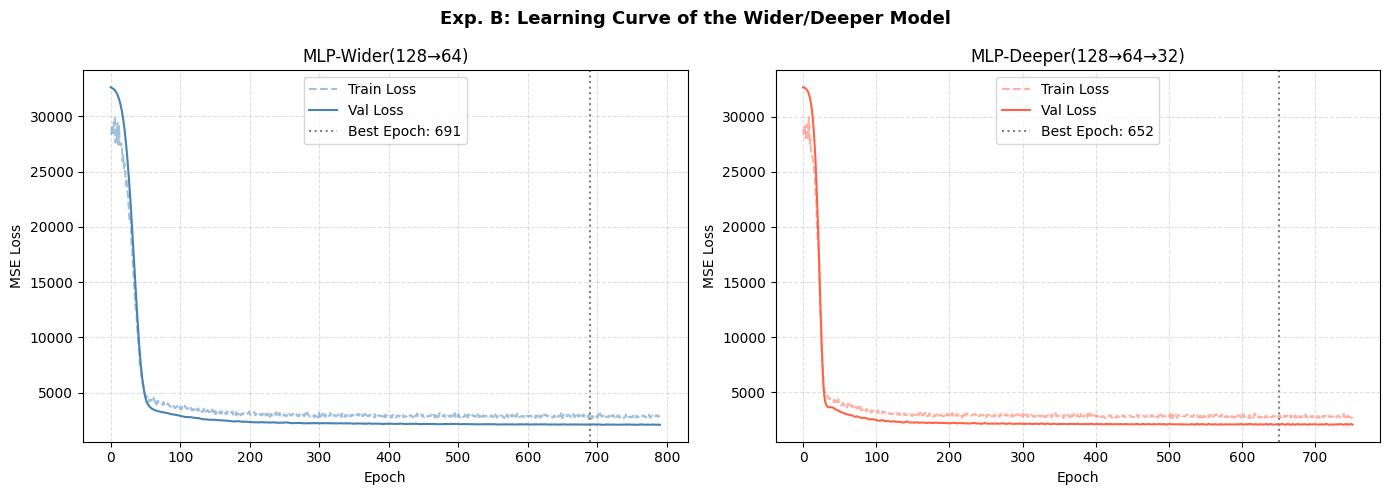


  모델                                       RMSE       R²        비고
--------------------------------------------------------------------
  [기준] MLP Baseline                     53.9787   0.4501    기준
  Ridge(alpha=0.1)                      53.5212   0.4593  -0.4575
  Ridge(alpha=1.0)                      56.1514   0.4049  +2.1727
  Ridge(alpha=10.0)                     67.4896   0.1403  +13.5109
  Lasso(alpha=0.1)                      52.9408   0.4710  -1.0379
  Lasso(alpha=1.0)                      58.2584   0.3594  +4.2797
  MLP-Wider(128→64)                     52.8140   0.4735  -1.1647
  MLP-Deeper(128→64→32)                 51.8621   0.4923  -2.1166
  [CV] MLP-Wider (5-Fold 평균)            55.2691   0.4822  +1.2904

  * CV 결과는 표준편차와 함께 해석해야 함
    5-Fold RMSE: 55.2691 ± 2.0970
    5-Fold R²:   0.4822 ± 0.0448


In [ ]:
# ── 학습 곡선 시각화 (실험 B) ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue", "tomato"]
for res, c, ax in zip(wider_results, colors, axes):
    ax.plot(res["train_losses"], label="Train Loss", color=c, alpha=0.5, linestyle="--")
    ax.plot(res["val_losses"],   label="Val Loss",   color=c)
    ax.axvline(res["best_epoch"]-1, color="gray", linestyle=":",
               label=f"Best Epoch: {res['best_epoch']}")
    ax.set_title(res["label"])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Exp. B: Learning Curve of the Wider/Deeper Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 전체 성능 비교 표 ────────────────────────────────────────────────────────
print()
print("=" * 68)
print(f"  {'모델':<35}  {'RMSE':>8}  {'R²':>7}  {'비고':>8}")
print("-" * 68)

all_results = (
    [{"label": "[기준] MLP Baseline", "rmse": 53.9787, "r2": 0.4501, "note": "이전 결과"}]
    + [{**r, "note": "선형"}  for r in linear_results]
    + [{**r, "note": "실험B"} for r in wider_results]
    + [{"label": "[CV] MLP-Wider (5-Fold 평균)",
        "rmse": np.mean(rmse_cv), "r2": np.mean(r2_cv),
        "note": "CV 추정"}]
)

baseline_rmse = 53.9787
for r in all_results:
    delta = r["rmse"] - baseline_rmse
    sign  = "+" if delta > 0 else ""
    delta_str = "  기준" if delta == 0 else f"{sign}{delta:.4f}"
    print(f"  {r['label']:<35}  {r['rmse']:>8.4f}  {r['r2']:>7.4f}  {delta_str}")

print("=" * 68)
print()
print("  * CV 결과는 표준편차와 함께 해석해야 함")
print(f"    5-Fold RMSE: {np.mean(rmse_cv):.4f} ± {np.std(rmse_cv):.4f}")
print(f"    5-Fold R²:   {np.mean(r2_cv):.4f} ± {np.std(r2_cv):.4f}")

---
## 결론 및 데이터 기반 판단

### A. 실험 결과 해석 원칙

1. **선형 모델과 MLP의 성능 차이가 작다면:**
   - 이 데이터에는 비선형 패턴이 거의 없다는 증거다.
   - MLP를 더 깊게/넓게 만드는 것보다 Feature Engineering이 더 효과적일 수 있다.
   - 예: 교호항(interaction terms), 다항 피처 추가 후 Ridge 적용

2. **선형 모델이 MLP보다 우수하다면:**
   - 딥러닝은 이 문제에 적합하지 않다. 과도한 파라미터, 적은 데이터가 원인.
   - Occam's Razor: 더 단순한 모델로 동등한 성능을 낼 수 있다면 단순한 모델을 선택한다.

3. **MLP-Wider/Deeper가 개선을 보인다면:**
   - 과소적합 진단이 올바랐으며, 용량 확장이 방향이다.
   - 이후에만 적절한 Dropout(0.1~0.2 수준)으로 미세 조정을 시도할 수 있을 것이다.


<br>

---
<br>


### B. 관측 결과의 데이터 기반 해석

* **사실 1: MLP-Deeper의 단일 분할 성능(51.86)은 낙관 편향이 있다.**
  * CV 결과(55.27 ± 2.10)가 단일 분할 MLP-Wider(52.81)보다 나빴다. 이것은 단일 분할의 RMSE 52~53대가 특정 데이터 분할에 유리하게 작동한 결과임을 시사한다.
  * **주장 가능한 실제 일반화 RMSE는 55.27 ± 2.10**이며, 기준선(53.98)과의 차이가 오차 범위 내에 들어온다.

* **사실 2: 선형 모델(Lasso 52.94)과 MLP의 격차가 1 RMSE 미만이다.**
  * 사전에 설정한 **해석 원칙 1번**에 완벽히 해당한다.
  * 이는 데이터 내 비선형 패턴이 제한적이거나, n=442라는 데이터 규모가 MLP의 비선형 학습 능력을 충분히 발휘하기에 부족하다는 명확한 증거이다.

* **사실 3: 모든 모델의 R²가 0.45~0.49에 머문다.**
  * 어떤 모델로도 타겟 변수 분산의 절반을 설명하지 못한다. 이는 모델 구조나 선택의 문제가 아닐 수 있다.
  * 원본 피처 10개만으로는 타겟 변수의 설명력에 근본적인 상한이 존재한다는 가능성을 검토해야 한다.

<br>

---
<br>

### C. 한계 및 다음 단계

| 항목 | 현재 상태 | 다음 단계 |
|------|-----------|----------|
| 평가 신뢰성 | 단일 분할 → CV | K-Fold 결과를 주 지표로 사용 |
| 피처 | 원본 10개 사용 | 다항 피처, 교호항 추가 탐색 |
| 하이퍼파라미터 | 수동 설정 | Optuna로 자동 탐색 |
| 모델 비교 | MLP 계열만 | XGBoost, RandomForest 추가 비교 |

<br>

<br>